In [35]:
import numpy as np 
import pandas as pd
from scipy.stats import norm, t, norminvgauss, levy_stable, genpareto
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
import plotly.express as px

import sys
sys.path.append("..")
from src.preprocessing import align_densities
from src.kde import verify_density_area 
from src.transformations import (
                            dens2lqd,
                            lqd2dens,
                            mLQDT,
                            obtain_lqds,
                            obtain_densities_from_lqd,
                            modes_of_variation,
                            compute_lqd_cut
                            )
import src.simulations as sim
from src.plotting import px_select_menu

# Monte Carlo Simulation Design

This section describes the Monte Carlo design used to evaluate the performance of the proposed density forecasting framework.

## Data Generating Process

Let $\{f_t\}_{t=1}^T$ be a sequence of probability density functions defined on a compact support $\mathcal{U} \subset \mathbb{R}$. Each $f_t$ is drawn from a flexible class of distributions, including:

- **Gaussian distribution**
$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

- **Student-$t$ distribution**
$$
f(x) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} 
\left(1 + \frac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

- **Skew-Student-t (Azzalini Type)**
\begin{equation}
f(x; \xi, \omega, \alpha, \nu) = \frac{2}{\omega} t_{\nu} \left( \frac{x - \xi}{\omega} \right) T_{\nu + 1} \left( \alpha \left( \frac{x - \xi}{\omega} \right) \sqrt{\frac{\nu + 1}{\nu + (\frac{x - \xi}{\omega})^2}} \right)
\end{equation}

- **Normal Inverse Gaussian (NIG)**
\begin{equation}
f(x; \alpha, \beta, \delta, \mu) = \frac{\alpha \delta K_1 \left( \alpha \sqrt{\delta^2 + (x - \mu)^2} \right)}{\pi \sqrt{\delta^2 + (x - \mu)^2}} \exp(\delta \sqrt{\alpha^2 - \beta^2} + \beta(x - \mu))
\end{equation}

<!-- 3. Levy Stable Distribution (Characteristic Function)
\begin{equation}
\ln \phi(t) = it\mu - |ct|^\alpha \left( 1 - i\beta \text{sgn}(t) \Phi \right)
\text{where } \Phi = \tan\left(\frac{\pi\alpha}{2}\right) \text{ if } \alpha \neq 1, \text{ and } \Phi = -\frac{2}{\pi} \ln|t| \text{ if } \alpha = 1
\end{equation} -->

- **Jump-Diffusion (Merton Model)**
\begin{equation}
f(x) = \sum_{n=0}^{\infty} \frac{e^{-\lambda} \lambda^n}{n!} \cdot \frac{1}{\sqrt{2\pi \sigma_n^2}} \exp \left( -\frac{(x - \mu_n)^2}{2\sigma_n^2} \right)
\end{equation}

<!-- 5. Generalized Pareto Distribution (GPD)
\begin{equation}
f(x; \sigma, \xi) = \frac{1}{\sigma} \left( 1 + \frac{\xi x}{\sigma} \right)^{-\left( \frac{1}{\xi} + 1 \right)}
\end{equation} -->

- **Spliced Normal-GPD Mixture**
\begin{cases} 
\frac{1-2\phi}{\beta} \left( 1 + \frac{\xi(-x-u)}{\beta} \right)^{-\left( \frac{1}{\xi} + 1 \right)} & \text{if } x < -u \\ 
\frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) & \text{if } -u \le x \le u \\ 
\frac{1-2\phi}{\beta} \left( 1 + \frac{\xi(x-u)}{\beta} \right)^{-\left( \frac{1}{\xi} + 1 \right)} & \text{if } x > u 
\end{cases}

where $Z_t \sim \mathcal{N}(0,1)$ and $N_t$ is a Poisson process.

To model densities in a Hilbert space, we apply a transformation $\Lambda_q(\cdot)$:

$$
Y_t(u) = \Lambda_q(f_t)(u) + X_t(u) + \varepsilon_t(u), \quad u \in \mathcal{U}.
$$

where $\varepsilon_t$ is a zero-mean noise process and $X_t$ captures the serial dependence structure.

---

## Functional Representation

The latent process $X_t$ is expanded in an orthonormal Fourier basis:

$$
X_t(u) = \sum_{k=1}^{d} \eta_{t,k} \, \phi_k(u),
$$

where the basis functions are defined as:

$$
\phi_{2k-1}(u) = \sqrt{2}\cos(\pi k u), \quad
\phi_{2k}(u) = \sqrt{2}\sin(\pi k u), \quad k \geq 1.
$$

The coefficient vector $\boldsymbol{\eta}_t = (\eta_{t,1}, \dots, \eta_{t,d})'$ follows a vector autoregressive process:

$$
\boldsymbol{\eta}_t = A \boldsymbol{\eta}_{t-1} + \boldsymbol{\xi}_t,
$$

where $A$ is a stable coefficient matrix and $\boldsymbol{\xi}_t$ is white noise.

---

## Inverse Transformation and Sampling

The simulated densities are obtained via the inverse transformation:

$$
\tilde{f}_t = \Lambda_q^{-1}(Y_t),
$$

followed by normalization to ensure that $\tilde{f}_t$ integrates to one.

From each density $\tilde{f}_t$, we generate an i.i.d. sample:

$$
\{x_{t,1}, \dots, x_{t,n}\} \sim \tilde{f}_t.
$$

---

## Estimation and Forecasting Procedure

For each Monte Carlo replication:

1. **Density Estimation**  
   Estimate $\hat{f}_t$ using kernel density estimation (KDE) based on $\{x_{t,1}, \dots, x_{t,n}\}$.

2. **Train-Test Split**

$$
\mathcal{T}_0 = \{\hat{f}_1, \dots, \hat{f}_{t_0}\}, \quad
\mathcal{T}_1 = \{\hat{f}_{t_0+1}, \dots, \hat{f}_T\}.
$$

3. **Transformation**

$$
\hat{Y}_t = \Lambda_q(\hat{f}_t)
$$

4. **Functional PCA (FPCA)**  
   Apply FPCA to $\{\hat{Y}_t\}_{t \in \mathcal{T}_0}$ to obtain:
   - Eigenfunctions $\{\hat{\psi}_k\}_{k=1}^d$
   - Scores $\hat{\eta}_{t,k}$

5. **Time Series Modeling**  
   Fit a VAR($p$) model to $\hat{\boldsymbol{\eta}}_t$.

6. **Forecasting and Reconstruction**

$$
\hat{Y}_{t+1}(u) = \sum_{k=1}^{d} \hat{\eta}_{t+1,k} \, \hat{\psi}_k(u)
$$

7. **Inverse Mapping**

$$
\hat{f}_{t+1} = \Lambda_q^{-1}(\hat{Y}_{t+1})
$$

---

## Evaluation

Forecast accuracy is assessed via:

$$
L\big(\hat{f}_{t+1}, f_{t+1}\big),
$$

where $L(\cdot,\cdot)$ may include:

- $L^2$ distance  
- Kullback--Leibler divergence  
- Jensen--Shannon divergence  

---

## Remarks

To assess the impact of estimation error, two scenarios are considered:

- **Oracle case:** the true densities $f_t$ are directly observed  
- **Estimated case:** densities are obtained via KDE  

## Base pdfs

In [36]:
# 1. Define a dense grid for the x-axis
# Using 1000 points makes the curve look perfectly smooth
m = 1000
x = np.linspace(-6, 6, m)

# 2. Calculate the "True" PDF values (not random samples)
pdf_t3     = sim.t_density(x, df=3)
pdf_t5     = sim.t_density(x, df=5)
pdf_normal = sim.normal_density(x)

pdf_mixture = sim.gaussian_mixture_density(
    x,
    weights=[0.9, 0.1],
    locs=[0, 0],
    scales=[1, 5]
)

pdf_mixture_t = sim.t_mixture_density(
        x,
    weights=[0.8, 0.2],
    dfs=[10, 3],
    locs=[0, 0],
    scales=[1, 2]
)

pdf_skewt = sim.skew_t_pdf(x, df=5, alpha=-3)  # Negative skew for market crashes
pdf_nig   = norminvgauss.pdf(x, a=1.5, b=-0.5) # Heavy tails + asymmetry
# pdf_stable = levy_stable.pdf(x, alpha=1.7, beta=-0.2) # Infinite variance potential
pdf_merton = sim.merton_jump_pdf(x, mu=0, sigma=0.5, lamb=1.0, muj=-1.0, sigmaj=0.5)
pdf_gpd    = genpareto.pdf(x, c=0.2, loc=0, scale=1) # Tail behavior focus
## Spliced normal GPD (SNGPD)
# Case A: Light tails (xi small)
y_light = sim.spliced_normal_gpd(x, u=1.5, xi=0.05)
# Case B: Heavy tails (xi large, typical for Bitcoin/High Volatility)
y_heavy = sim.spliced_normal_gpd(x, u=1.5, xi=0.4)

In [24]:
# 1. Consolidate your existing arrays into a DataFrame
# (Assuming x, pdf_t3, pdf_t5, etc., are already defined in your environment)
df = pd.DataFrame({
    "x": x,
    "Student-t (df=3)": pdf_t3,
    "Student-t (df=5)": pdf_t5,
    "Gaussian mixture": pdf_mixture,
    "t mixture": pdf_mixture_t,
    "Normal": pdf_normal,
    "Skew-t (df=5, α=-3)": pdf_skewt,
    "NIG (heavy tails)": pdf_nig,
    # "Levy Stable (α=1.7)": pdf_stable,
    "Merton Jumps": pdf_merton,
    # "GPD": pdf_gpd,
    "SNGPD": y_light
})

# 2. Generate the simplified plot
fig = px.line(
    df, 
    x="x", 
    y=[col for col in df.columns if col != "x"],
    title="Synthetic Densities: Comparative Overview",
    labels={"value": "Density", "variable": "Distribution", "x": "Returns"},
    template="plotly_dark"
)

# 3. Apply uniform styling to all traces
fig.update_traces(line=dict(width=2))

# 4. Final layout cleanup
fig.update_layout(
    legend_title_text='Model Type',
    # hovermode="x unified",
    # xaxis=dict(range=[-8, 8]), # Focusing on the relevant distribution area
    yaxis=dict(title="Probability Density")
)

px_select_menu(fig)
fig.show()

## Transformations

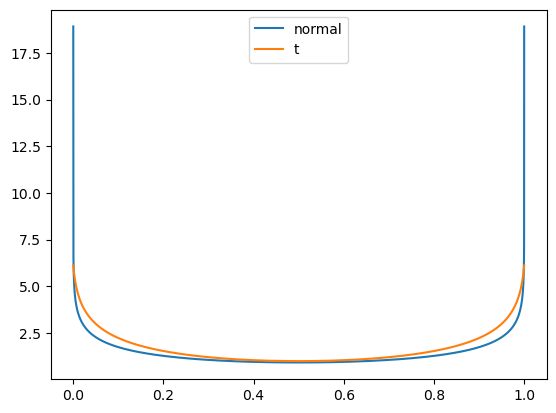

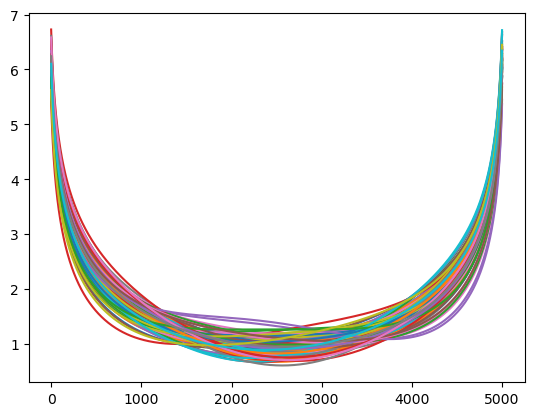

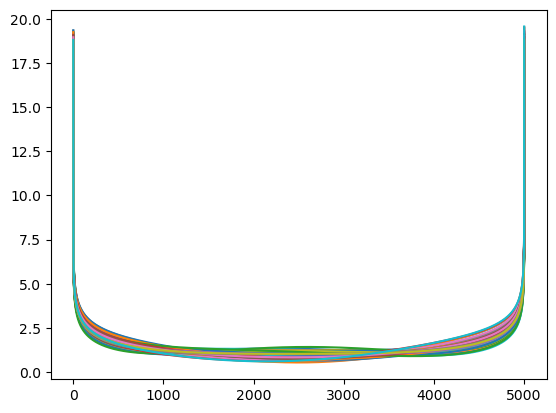

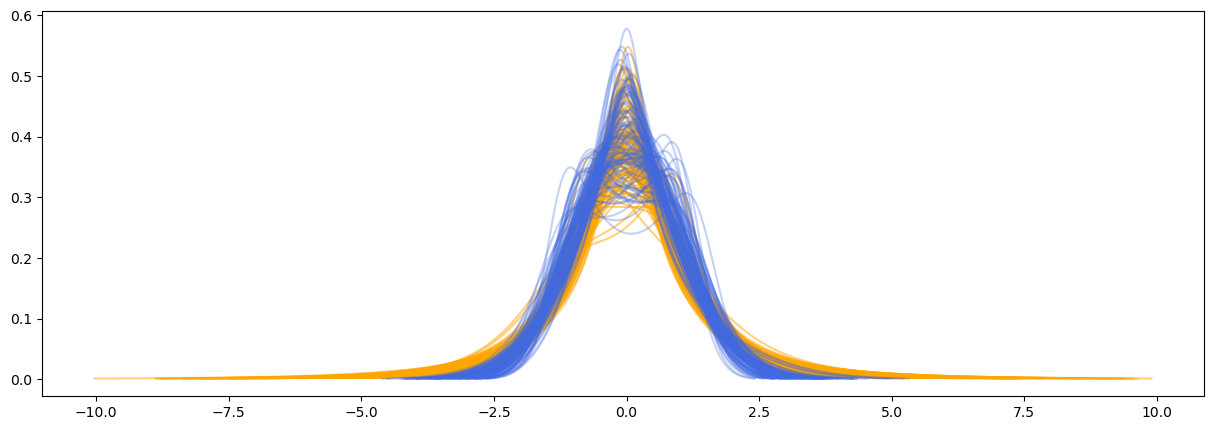

In [89]:
lqd_support = np.linspace(0,1,5001)
t0_ = x[np.argmin(np.abs(x))]
lqdsup, lqd_t, c = dens2lqd(
                        dens = pdf_t3, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = t0_,
                        verbose=True
                        )
lqdsup, lqd_n, c = dens2lqd(
                        dens = pdf_normal, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = t0_,
                        verbose=True
                        )
plt.figure()

plt.plot(lqdsup, lqd_n, label="normal")
plt.plot(lqdsup, lqd_t, label="t")

plt.legend()
plt.show()
# lqd_t = lqd
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = sim.simulate_dependent_densities(100, lqd_t, phis)
df_lqds_t = pd.DataFrame(curves)
df_lqds_t.plot(legend=False)
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = sim.simulate_dependent_densities(100, lqd_n, phis)
df_lqds_n = pd.DataFrame(curves)
df_lqds_n.plot(legend=False)
bkw_supports_t, bkw_densities_t = obtain_densities_from_lqd(
                                                            df_lqds_t,
                                                            lqd_support,
                                                            c_=[c for i in range(df_lqds_t.shape[1])],
                                                            t_=[0 for i in range(df_lqds_t.shape[1])],
                                                            verbose=False
                                                            )

bkw_supports_n, bkw_densities_n = obtain_densities_from_lqd(
                                                            df_lqds_n,
                                                            lqd_support,
                                                            c_=[c for i in range(df_lqds_t.shape[1])],
                                                            t_=[0 for i in range(df_lqds_t.shape[1])],
                                                            verbose=False
                                                            )
plt.figure(figsize=(15,5))
for i in range(bkw_densities_t.shape[1]):
    plt.plot(bkw_supports_t.iloc[:,i], bkw_densities_t.iloc[:,i], c="orange", label= "t-student", alpha=.5)

for i in range(bkw_densities_n.shape[1]):
    plt.plot(bkw_supports_n.iloc[:,i], bkw_densities_n.iloc[:,i], c="royalblue", label="normal", alpha=.3)
plt.show()

## Sampling from KDE

[]

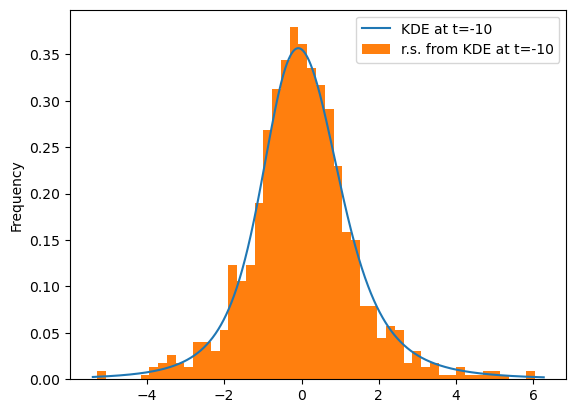

In [92]:
t=-10

returns_day_1 = sim.sample_from_density(bkw_supports_t.iloc[:, t], bkw_densities_t.iloc[:, t])
plt.plot(bkw_supports_t.iloc[:, t], bkw_densities_t.iloc[:, t], label=f"KDE at t={t}")
pd.Series(returns_day_1).plot(kind="hist", bins=50,density=True, label=f"r.s. from KDE at t={t}")

plt.legend()

plt.plot()

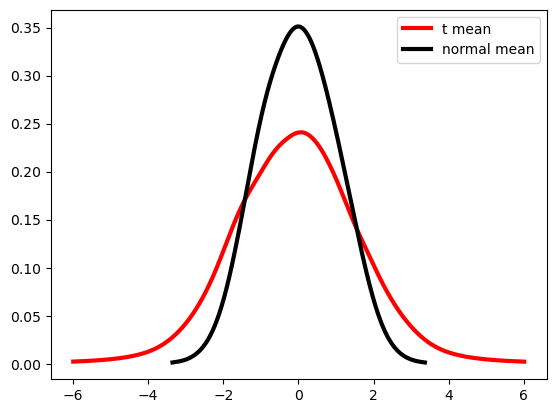

In [93]:
# Mean comparison
plt.plot(
    bkw_supports_t.iloc[:,0],
    bkw_densities_t.mean(axis=1),
    c="red",
    lw=3,
    label="t mean"
)

plt.plot(
    bkw_supports_n.iloc[:,0],
    bkw_densities_n.mean(axis=1),
    c="black",
    lw=3,
    label="normal mean"
)

plt.legend()

plt.show()

# Whole dataset

In [60]:
distribution = df.columns[1]
print(f"Simulating data for {distribution}")
T = 300
series = df[distribution].values[:T]   # enforce length T

array = np.tile(series, (m, 1))

Simulating data for Student-t (df=3)


In [64]:
distribution = df.columns[1]
density = df[distribution].values   # shape (1000,)

T = 300

matrix = np.tile(density[:, None], (1, T))

dates = pd.date_range(start="2020-01-01", periods=T, freq="D")
df_densities = pd.DataFrame(matrix, columns=dates)
df_densities

,2020-01-01,2020-01-02,2020-01-03,2020-01-04,2020-01-05,2020-01-06,2020-01-07,2020-01-08,2020-01-09,2020-01-10,...,2020-10-17,2020-10-18,2020-10-19,2020-10-20,2020-10-21,2020-10-22,2020-10-23,2020-10-24,2020-10-25,2020-10-26
0,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,...,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195,0.002195
1,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,...,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212
2,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,...,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228
3,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,...,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245
4,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,...,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,...,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261,0.002261
996,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,...,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245,0.002245
997,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,...,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228,0.002228
998,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,...,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212,0.002212


In [ ]:
df_supports = df_densities.copy()
for col in df_supports.columns:
    df_supports[col] = x

In [65]:
bovespa_mLQDT = mLQDT(
                    df_densities,
                    df_supports
                )
bovespa_mLQDT.densities_to_lqdensities(verbose=False)

In [68]:
def simulate_dependent_densities(
    n_days,
    lqd_template,
    phis,
    sigma=0.1,
    start_date="2020-01-01",
    freq="B",
    normalize=False
):
    """
    Simulates a sequence of LQD curves with temporal dependence.
    Each column = one function (day), rows = grid points.
    
    Returns:
        df_lqds: DataFrame (nt x n_days)
        scores: latent AR(1) scores (K x n_days)
    """
    
    nt = len(lqd_template)
    K = len(phis)
    u = np.linspace(0, 1, nt)
    
    # --- 1. Simulate AR(1) scores ---
    scores = np.zeros((K, n_days))
    
    for k in range(K):
        shocks = np.random.normal(scale=sigma, size=n_days)
        for t in range(1, n_days):
            scores[k, t] = phis[k] * scores[k, t-1] + shocks[t]
    
    # --- 2. Basis functions (Fourier cosine) ---
    basis = np.array([
        np.sqrt(2) * np.cos(np.pi * (k + 1) * u)
        for k in range(K)
    ])  # shape: (K, nt)
    
    # --- 3. Build perturbations ---
    perturbations = (scores.T @ basis).T  # (nt x n_days)
    
    # --- 4. Add template ---
    simulated_lqds = lqd_template[:, None] + perturbations  # (nt x n_days)
    
    # --- 5. Optional normalization (important if these represent densities/log-densities) ---
    if normalize:
        # Example: center each curve (depends on your Λ_q definition)
        simulated_lqds = simulated_lqds - simulated_lqds.mean(axis=0)
    
    # --- 6. Create date columns ---
    dates = pd.date_range(start=start_date, periods=n_days, freq=freq)
    
    df_lqds = pd.DataFrame(simulated_lqds, columns=dates)
    df_lqds.index.name = "u"
    
    return df_lqds, scores

In [ ]:
curves, _ = sim.simulate_dependent_densities(100, lqd_t, phis)